In [1]:
from flare_reader import list_ar_mvts, read_mvts
import numpy as np

import pandas as pd
ar_ts_path = '../new-data/'



In [2]:
ar_file_list = list_ar_mvts(ar_ts_path)

In [3]:
ar_file_paths = [ar_ts_path + ar_file for ar_file in ar_file_list]

In [4]:
ts_df = read_mvts(ar_file_paths[1])

In [5]:
# for column in ts_df.columns:
ts_df.head(3)

,TOTUSJH,TOTBSQ,TOTPOT,TOTUSJZ,ABSNJZH,SAVNCPP,USFLUX,TOTFZ,MEANPOT,EPSZ,...,MEANJZH,TOTFY,MEANJZD,MEANALP,TOTFX,EPSY,EPSX,CRVAL1,CRLN_OBS,R_VALUE
Timestamp,,,,,,,,,,,,,,,,,,,,,
2013-11-30 04:24:00,28.401735,2.673821e+08,3.657369e+21,5.629068e+11,1.483084,3.648499e+10,4.061730e+20,-2.251159e+23,4839.983524,-0.633959,...,0.002606,2.721143e+22,0.015036,0.006789,6.907338e+22,-0.076631,-0.194521,170.322372,248.665878,0.0
2013-11-30 04:36:00,49.329827,5.824699e+08,5.879748e+21,8.327670e+11,8.753134,1.373952e+11,7.927597e+20,-4.323986e+23,4422.951113,-0.558983,...,0.008744,-1.999508e+22,-0.268168,0.019279,2.279630e+23,0.025849,-0.294699,170.324249,248.556656,0.0
2013-11-30 04:48:00,53.242643,6.358723e+08,6.389416e+21,9.726945e+11,9.714547,3.143951e+11,8.863257e+20,-4.755058e+23,4122.663106,-0.563084,...,0.008324,-2.386419e+22,-0.526348,0.019548,2.360612e+23,0.028259,-0.279539,170.326050,248.447449,0.0


In [6]:
rows = [u'TOTUSJH', u'TOTBSQ', u'TOTPOT', u'TOTUSJZ', u'ABSNJZH', u'SAVNCPP',
       u'USFLUX', u'TOTFZ', u'MEANPOT', u'EPSZ', u'SHRGT45', u'MEANSHR',
       u'MEANGAM', u'MEANGBT', u'MEANGBZ', u'MEANGBH', u'MEANJZH', u'TOTFY',
       u'MEANJZD', u'MEANALP', u'TOTFX', u'EPSY', u'EPSX', u'CRVAL1',
       u'CRLN_OBS', u'R_VALUE']


In [7]:
# nan_check_df
nan_check_df = pd.DataFrame(index = rows)

empty_data_list = []
i = 1
for ar_file_p in ar_file_paths:
    
    
    ar_str =  ar_file_p.split('/new-data/')[1].rstrip('.csv')
    try:
        ts_df = read_mvts(ar_file_p)
        nan_series = ts_df.isna().sum()
        nan_check_df[ar_str] = nan_series
    except Exception:
        empty_data_list.append(ar_str)
    
nan_check_df.sum(axis=1)

TOTUSJH       2269
TOTBSQ        2250
TOTPOT        2295
TOTUSJZ       2269
ABSNJZH       2269
SAVNCPP       2212
USFLUX        2250
TOTFZ         2250
MEANPOT      73840
EPSZ         73795
SHRGT45      73840
MEANSHR      71545
MEANGAM      72162
MEANGBT      73820
MEANGBZ      73814
MEANGBH      73814
MEANJZH      73814
TOTFY         2250
MEANJZD      73814
MEANALP      73820
TOTFX         2250
EPSY         73795
EPSX         73795
CRVAL1           0
CRLN_OBS         0
R_VALUE     119431
dtype: int64

In [ ]:
nan_check_df.to_csv("nan_param_summary.csv")

In [8]:
zero_nan_check_df = pd.DataFrame(index = rows)

empty_data_list = []
i = 1
for ar_file_p in ar_file_paths:
    
    ar_str =  ar_file_p.split('/new-data/')[1].rstrip('.csv')
    try:
        ts_df = read_mvts(ar_file_p)
        df_zero = ts_df == 0
        nan_check = ts_df.isna().sum()
        zero_check = df_zero.sum()
        
        zero_nan_check_df[ar_str] = nan_check + zero_check
    except Exception:
        empty_data_list.append(ar_str)
    


In [ ]:
ts_df = read_mvts('../new-data/2516.csv')

df_zero = ts_df == 0
nan_check = ts_df.isna().sum()
zero_check = df_zero.sum()
nan_check + zero_check
print ''

In [9]:
zero_nan_check_df.sum(axis=1)

TOTUSJH       73814
TOTBSQ        73795
TOTPOT        73840
TOTUSJZ       73814
ABSNJZH       73814
SAVNCPP       73759
USFLUX        73795
TOTFZ         73795
MEANPOT       73840
EPSZ          73795
SHRGT45       73840
MEANSHR      184128
MEANGAM       72162
MEANGBT       73820
MEANGBZ       73814
MEANGBH       73814
MEANJZH       73814
TOTFY         73795
MEANJZD       73814
MEANALP       73820
TOTFX         73795
EPSY          73795
EPSX          73795
CRVAL1            0
CRLN_OBS          0
R_VALUE     1431607
dtype: int64

In [10]:
ar_lengths = {}

empty_data_list = []
i = 1
for ar_file_p in ar_file_paths:
    
    ar_str =  ar_file_p.split('/new-data/')[1].rstrip('.csv')
    try:
        ts_df = read_mvts(ar_file_p)
        
        ar_lengths[ar_str] = ts_df.shape[0]
        
    except Exception:
        ar_lengths[ar_str] = 0
    


In [11]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


In [12]:
arl_df = pd.DataFrame.from_dict(ar_lengths, orient='index')
arl_df = arl_df / 5.0

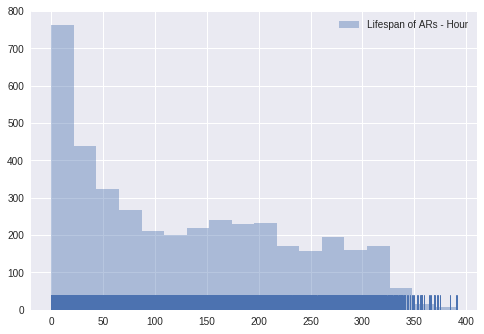

In [13]:
sns.distplot(arl_df, kde=False, norm_hist=False, rug = True, label = 'Lifespan of ARs - Hour')
plt.legend()

/home/baydin2/anaconda2/lib/python2.7/site-packages/seaborn/categorical.py:1428: FutureWarning: remove_na is deprecated and is a private function. Do not use.
  stat_data = remove_na(group_data)


Text(0,0.5,u'Total number of zero or NaN values')

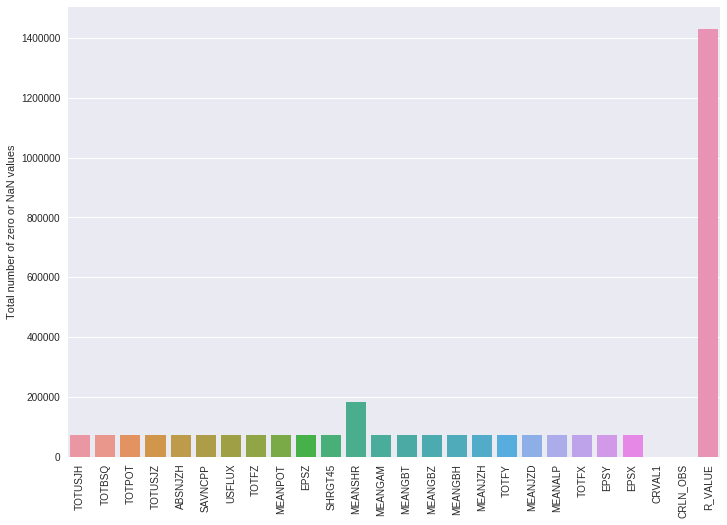

In [14]:
summary_df = zero_nan_check_df.sum(axis=1)
sns.set(rc={'figure.figsize':(11.7,8.27)})
g= sns.barplot( summary_df.index, summary_df )
plt.xticks(rotation=90)
plt.ylabel("Total number of zero or NaN values")


Text(0,0.5,u'Total number of NaN values')

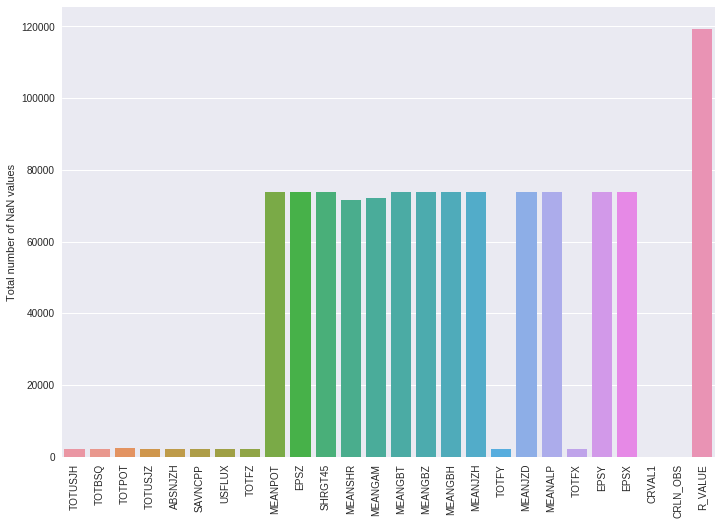

In [16]:
nan_summary_df = nan_check_df.sum(axis=1)
sns.set(rc={'figure.figsize':(11.7,8.27)})
g= sns.barplot( nan_summary_df.index, nan_summary_df )
plt.xticks(rotation=90)
plt.ylabel("Total number of NaN values")

/home/baydin2/anaconda2/lib/python2.7/site-packages/statsmodels/nonparametric/kernels.py:128: RuntimeWarning: divide by zero encountered in true_divide
  return (1. / np.sqrt(2 * np.pi)) * np.exp(-(Xi - x)**2 / (h**2 * 2.))
/home/baydin2/anaconda2/lib/python2.7/site-packages/statsmodels/nonparametric/kernels.py:128: RuntimeWarning: invalid value encountered in true_divide
  return (1. / np.sqrt(2 * np.pi)) * np.exp(-(Xi - x)**2 / (h**2 * 2.))
/home/baydin2/anaconda2/lib/python2.7/site-packages/statsmodels/nonparametric/_kernel_base.py:514: RuntimeWarning: invalid value encountered in divide
  dens = Kval.prod(axis=1) / np.prod(bw[iscontinuous])
/home/baydin2/anaconda2/lib/python2.7/site-packages/matplotlib/contour.py:1533: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/home/baydin2/anaconda2/lib/python2.7/site-packages/matplotlib/contour.py:1534: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())
/home/baydin2

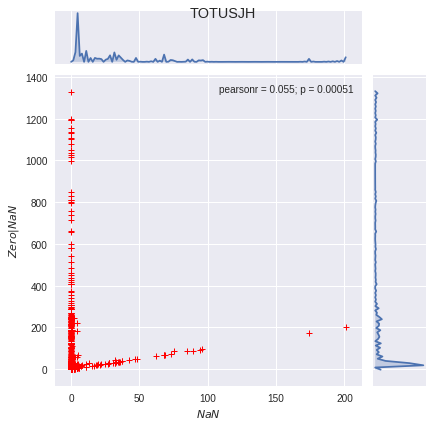

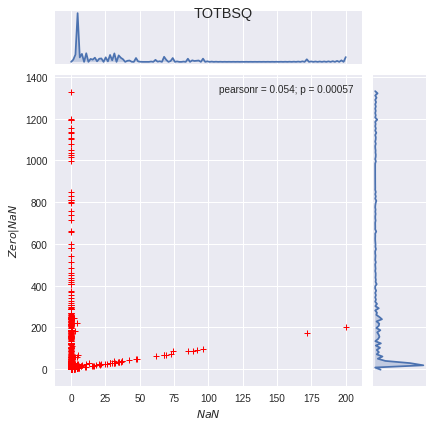

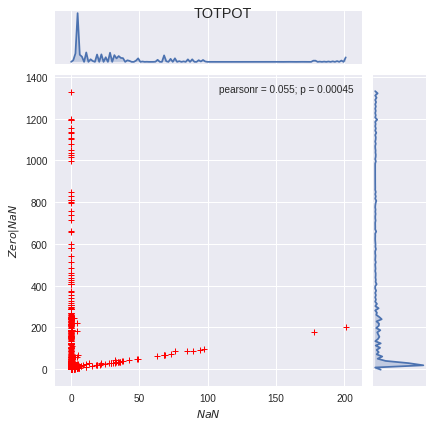

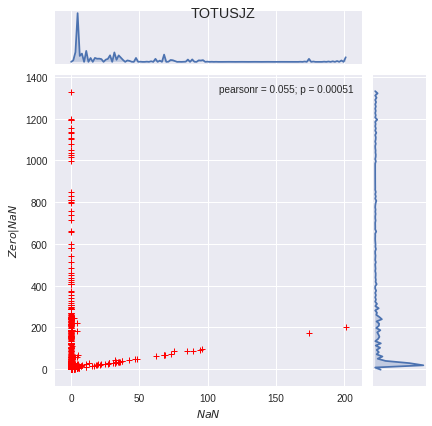

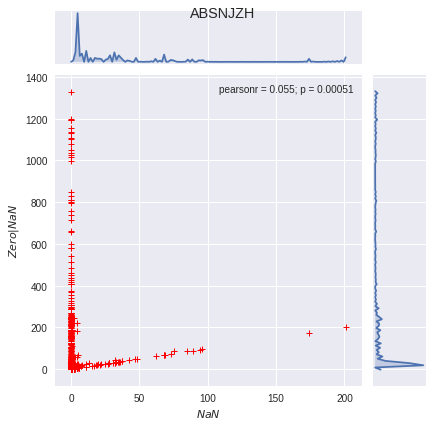

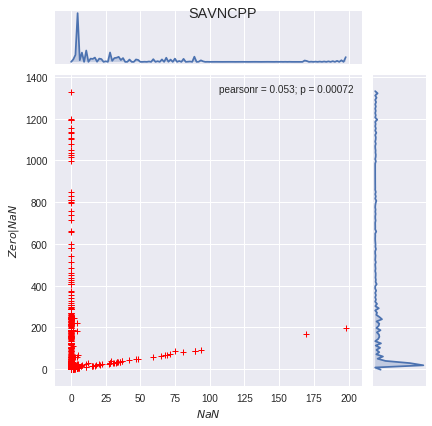

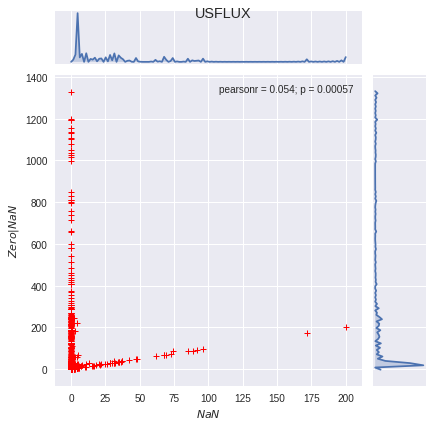

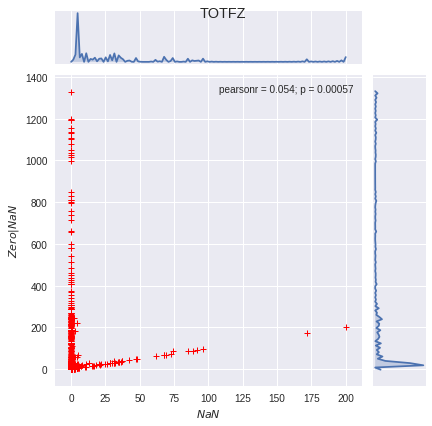

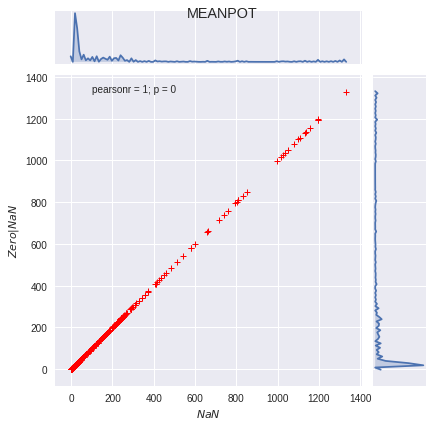

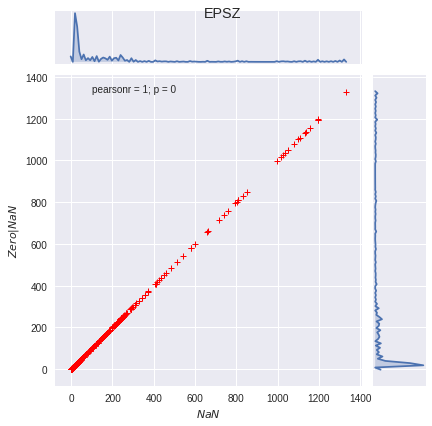

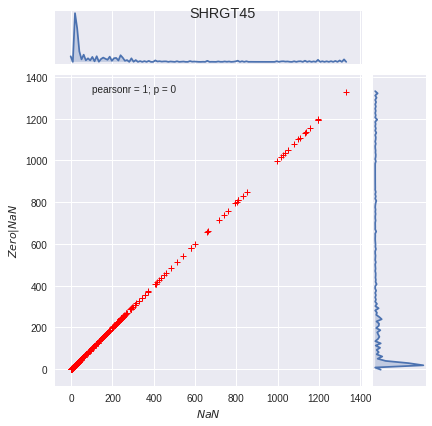

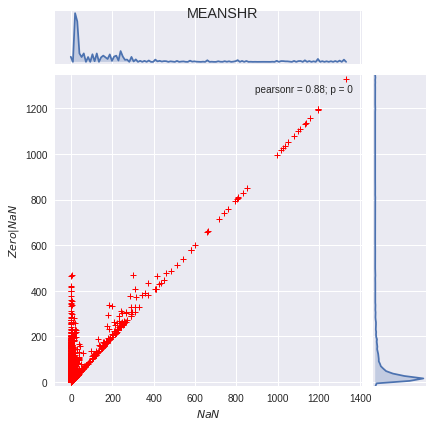

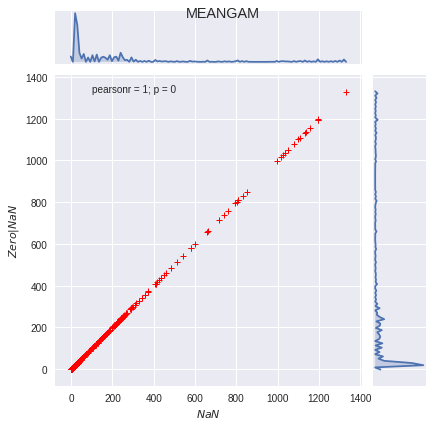

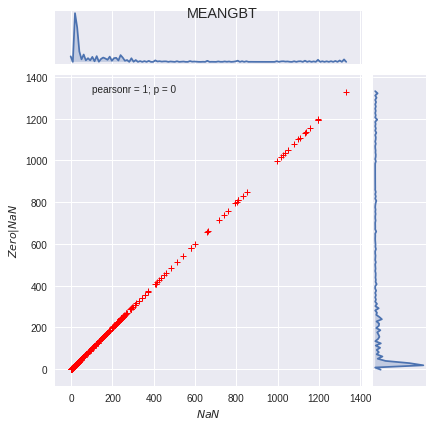

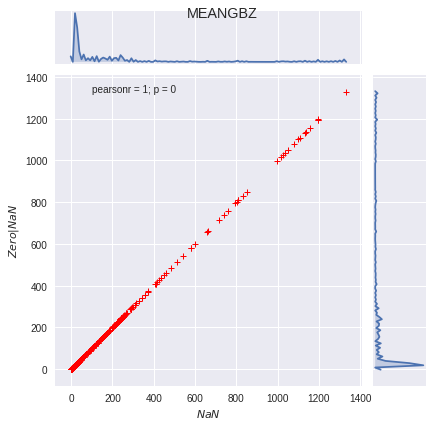

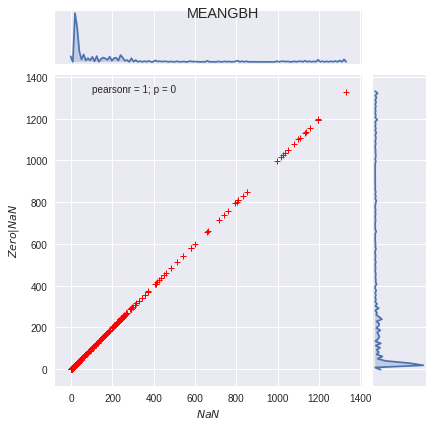

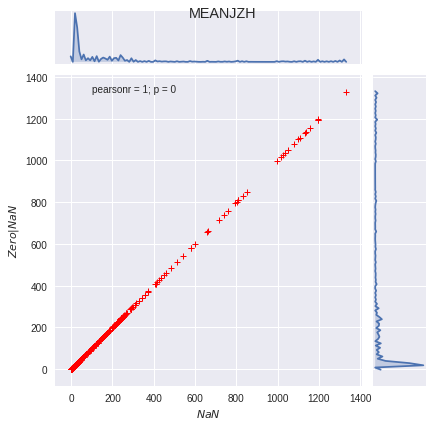

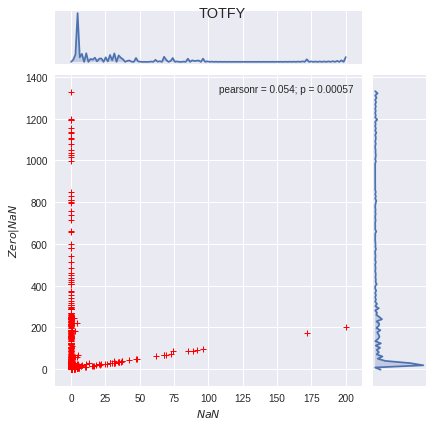

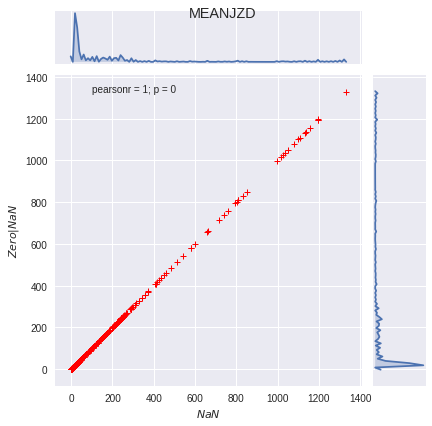

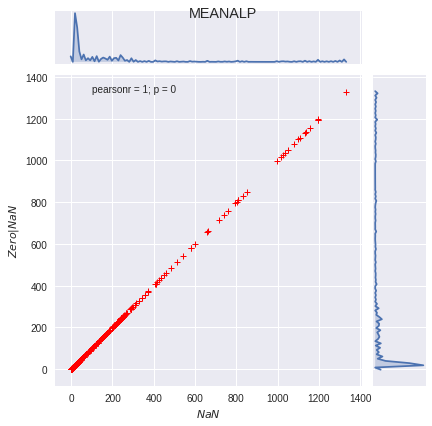

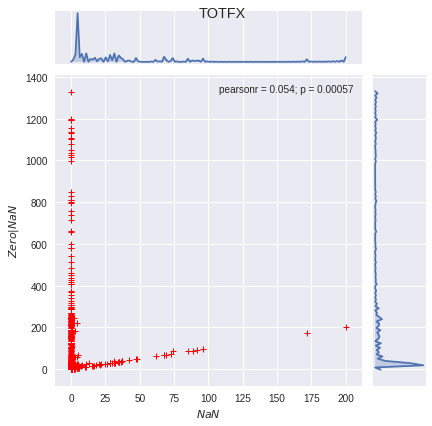

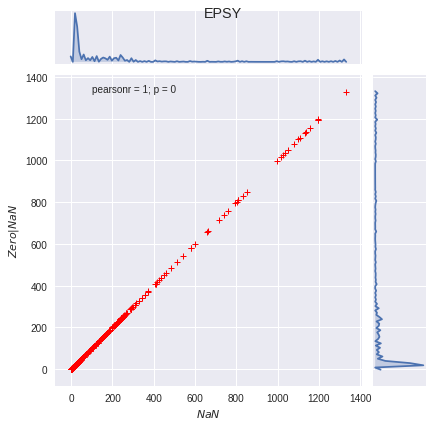

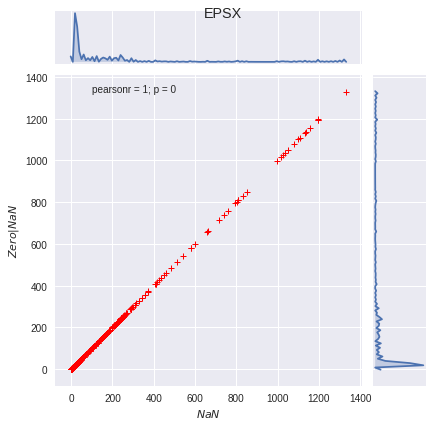

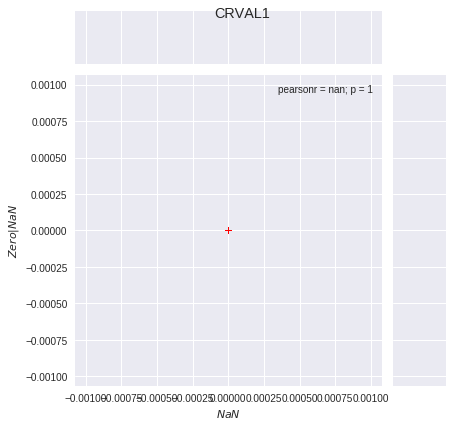

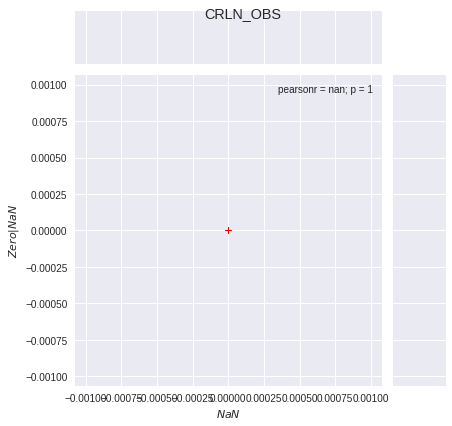

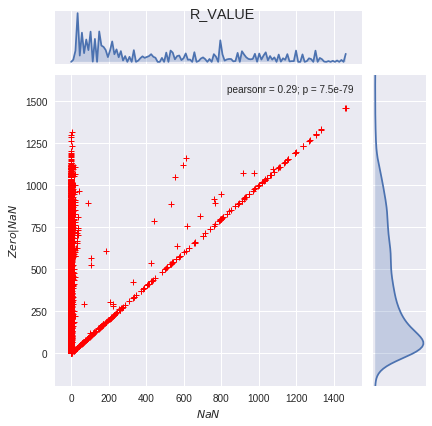

In [17]:
# f, axes = plt.subplots(2, 2)

i = 0
for column in rows:
    nans = nan_check_df.T[column]
    zns = zero_nan_check_df.T[column]

    nans = nans.rename('NaN')
    zns = zns.rename('ZN')

    df = pd.concat([nans, zns], axis=1)

    cmap = sns.cubehelix_palette(light=1, as_cmap=True)
    g= sns.jointplot(x="NaN", y="ZN", data=df, kind="kde", cmap=cmap);
    g.plot_joint(plt.scatter, c="r", s=30, linewidth=1, marker="+", )
    g.ax_joint.collections[0].set_alpha(0)
    g.set_axis_labels("$NaN$", "$Zero|NaN$");
    g.fig.suptitle(column)


In [ ]:
ts_df = read_mvts('../new-data/6315.csv')


# ar_lengths = {}

# empty_data_list = []
# i = 1
# for ar_file_p in ar_file_paths:
    
#     ar_str =  ar_file_p.split('/new-data/')[1].rstrip('.csv')
#     try:
#         ts_df = read_mvts(ar_file_p)
        
#         ar_lengths[ar_str] = ts_df.shape[0]
        
#     except Exception:
#         ar_lengths[ar_str] = 0
    


In [18]:
# ts_df[ (ts_df.index.to_series().diff() - pd.Timedelta('12 minutes')) == pd.Timedelta('0 seconds') ]
# (ts_df.index - ts_df.index.shift(12, freq='M'))
# ts_df.index.to_series().diff()



# alt = ts_df[ (ts_df.index.to_series().diff() - pd.Timedelta('12 minutes')) == pd.Timedelta('0 seconds') ]

ar_ts_checks = {}

empty_data_list = []
i = 1
for ar_file_p in ar_file_paths:
    
    ar_str =  ar_file_p.split('/new-data/')[1].rstrip('.csv')
    try:
        ts_df = read_mvts(ar_file_p)
        ratio = np.sum( (ts_df.index.to_series().diff() - pd.Timedelta('12 minutes')) != pd.Timedelta('0 seconds') ) / float(ts_df.shape[0])
        ar_ts_checks[ar_str] = ratio
        
    except Exception:
        ar_ts_checks[ar_str] = 0
    
# sns.barplot(x=ts_df.index.to_series(), y=ts_df.index.to_series().diff())

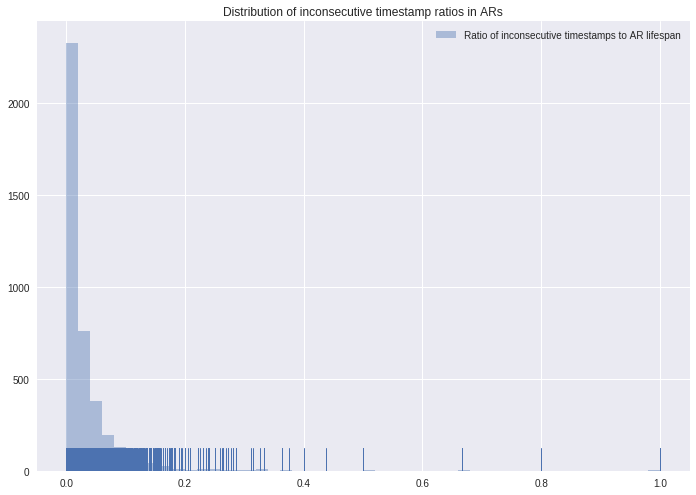

In [19]:
tsc_df = pd.DataFrame.from_dict(ar_ts_checks, orient='index')
sns.distplot(tsc_df, kde=False, norm_hist=False, rug = True, label = 'Ratio of inconsecutive timestamps to AR lifespan')
plt.title('Distribution of inconsecutive timestamp ratios in ARs')
plt.legend()


In [20]:
ar_ts_ratios = {}

empty_data_list = []
i = 1
for ar_file_p in ar_file_paths:
    
    ar_str =  ar_file_p.split('/new-data/')[1].rstrip('.csv')
    try:
        ts_df = read_mvts(ar_file_p)
        available = ts_df.shape[0]
        actual_count = (ts_df.index.to_series().values[ ts_df.shape[0] - 1] - ts_df.index.to_series().values[0]) / pd.Timedelta('12 minutes')
        
        ratio = float(available) / float(actual_count + 1)
        if ratio > 1.0 or ratio != ratio:
            print '\tAvailable',available,'\tActual',actual_count,'\tRatio',ratio
            print '\tStart: ',ts_df.index.to_series().values[0]
            print '\tEnd:   ',ts_df.index.to_series().values[ ts_df.shape[0] - 1]
        ar_ts_ratios[ar_str] = ratio
        
    except Exception:
#         ar_ts_ratios[ar_str] = -1
        print 'There was a problem with file: ', ar_str


There was a problem with file:  4395
There was a problem with file:  6850
There was a problem with file:  report_log_correction.txt


4054


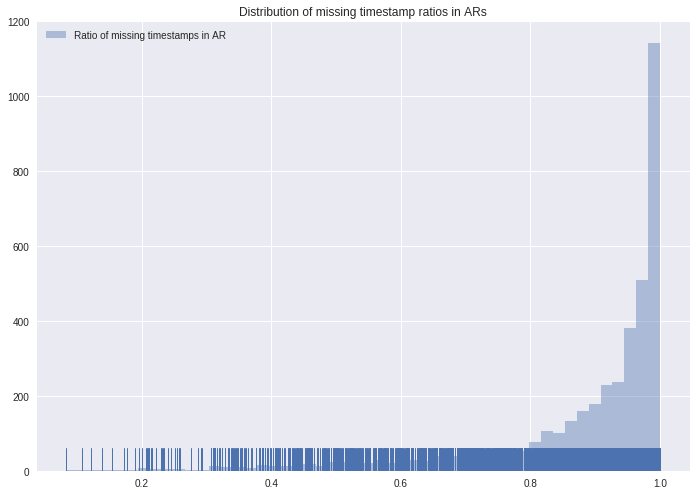

In [21]:
tsr_df = pd.DataFrame.from_dict(ar_ts_ratios, orient='index')
print tsr_df.shape[0]
tsr_df = tsr_df[~tsr_df.isna()]


sns.distplot(tsr_df, kde=False, norm_hist=False, rug = True, label = 'Ratio of missing timestamps in AR')
plt.title('Distribution of missing timestamp ratios in ARs')
plt.legend()